# SHAP Analysis for feature importance 
### Topomaps of feature importance

### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, GroupKFold, RandomizedSearchCV


from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    log_loss
)

from xgboost import XGBClassifier
from scipy.stats import uniform, randint, loguniform
import shap

random_state = 42

### Load data

In [2]:
both_df = pd.read_csv("both_intervals_features.csv")
p600_df = pd.read_csv("p600_features.csv")
n400_df = pd.read_csv("n400_features.csv")

### Electrodes common to all four original datasets

In [3]:
electrodes = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'PO9', 'O1', 'Oz', 'O2', 'PO10']

In [4]:
def split(df, random_state):
    df = df.copy() # copy to not break anything

    df["label"] = (df["Cloze"] > 0).astype(int) # cloze = 0 -> class 0 else class = 1

    cloze = df["Cloze"]  # keep it for the cloze performance analysis

    X = df.drop(columns=["Cloze", "label", "trial_global", "Trial", "site", "subject_global"]) # only keep features for training
    y = df["label"] # target variable 
    groups = df["subject_global"] # for subject-based splitting and grid search

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state) # 80-20 split with subjects as group to avoid data leakage
    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    groups_train = groups.iloc[train_idx]
    groups_test = groups.iloc[test_idx]

    cloze_test = cloze.iloc[test_idx]  # also split original cloze to keep track of shuffling and splitting of each seed

    return X_train, X_test, y_train, y_test, groups_train, groups_test, cloze_test

### Fit linear SHAP over 10 seeds -> store values per sample and per seed -> average over samples first and then over seeds -> get mean feature importance (one value) per feature + all raw SHAP values for plotting

In [5]:
# Use best hyperparameters (found in the FINAL_LR notebook using nested CV)
final_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        solver="lbfgs",
        C=0.001,
        max_iter=5000
    ))
])

all_feature_importance = []
all_shap_values = []
all_X_test = []
feature_names = None

# Run SHAP across 10 seeds for stable results
for seed in range(10):
    X_train, X_test, y_train, y_test, _, _, _ = split(both_df, seed)

    # save feature names for plotting
    if feature_names is None:
        feature_names = X_train.columns

    final_lr.fit(X_train, y_train) # fit model on the training data

    scaler = final_lr.named_steps['scaler'] # scale for SHAP because it doesn't work with Pipeline -> Consistency with the training, hyperparameter tuning and evaluation
    lr = final_lr.named_steps['model'] # extract the model from the pipeline

    X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns) # manually scale

    X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns) # scale manually

    # Use linear SHAP because we are using logistic regression as the model
    explainer = shap.LinearExplainer(lr, X_train_scaled) # SHAP learns from the training set
    shap_vals = explainer(X_test_scaled).values # feature importance at sample level

    all_shap_values.append(shap_vals) # store feature importance for each sample in the test set for each feature 
    all_X_test.append(X_test_scaled) # also store the associated samples from the test set

    # average over samples first
    feature_importance = np.mean(shap_vals, axis=0)

    all_feature_importance.append(feature_importance) # append to the feature importance over seeds

mean_feature_importance = np.mean(np.stack(all_feature_importance), axis=0) # average over seeds
all_shap_values = np.vstack(all_shap_values)
all_X_test = pd.concat(all_X_test, axis=0).reset_index(drop=True) 

In [6]:
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": mean_feature_importance}) # create dataframe with column names

top_features = feature_importance_df.sort_values(by="importance", ascending=False)

print(top_features.head(10))

             feature  importance
361  Oz_mean_400_500    0.003051
532   T8_std_700_800    0.002804
79   CP5_std_400_500    0.002222
449    P8_zc_800_900    0.002047
287   Fp1_zc_800_900    0.001995
285   Fp1_zc_600_700    0.001837
303   Fp2_zc_600_700    0.001803
241  FC5_std_400_500    0.001792
534    T8_zc_300_400    0.001710
447    P8_zc_600_700    0.001681


### Extract parsed feature names for plotting

In [7]:
def parse_feature_names(feat):
    parts = feat.split("_") # split at _ because feature names are Pz_mean_600_700
    electrode = parts[0] # channel
    feature_type = parts[1] # mean/std/zc
    time_window = "_".join(parts[2:]) # last two parts -> an interval
    return electrode, feature_type, time_window

parsed = feature_importance_df["feature"].apply(parse_feature_names) # parse the name of all the features in the dataframe for plotting

# extract parts of the feature names
feature_importance_df["electrode"] = parsed.apply(lambda x: x[0])
feature_importance_df["type"] = parsed.apply(lambda x: x[1])
feature_importance_df["window"] = parsed.apply(lambda x: x[2])

### Compute the mean feature importance per channel

In [8]:
channel_importance = (feature_importance_df.groupby("electrode")["importance"].mean()) # groupp by electrode and average feature importance

### Identify the single most important feature per channel based on absolute feature importace

In [9]:
feature_importance_df["abs_importance"] = feature_importance_df["importance"].abs() # extract  largest feature importance based on the abs, cannot use max because there might be larger abs of negative values

# extract the single most importance feature per channel
# Locate the feature with the highest absolute importance at the electrode level
best_features = (feature_importance_df.loc[feature_importance_df.groupby("electrode")["abs_importance"].idxmax()].reset_index(drop=True))

print(best_features)

             feature  importance electrode  type   window  abs_importance
0     C3_std_400_500    0.001047        C3   std  400_500        0.001047
1     C4_std_400_500    0.000632        C4   std  400_500        0.000632
2     CP1_zc_800_900    0.000883       CP1    zc  800_900        0.000883
3    CP2_std_700_800   -0.000779       CP2   std  700_800        0.000779
4    CP5_std_400_500    0.002222       CP5   std  400_500        0.002222
5     CP6_zc_500_600   -0.001778       CP6    zc  500_600        0.001778
6      Cz_zc_600_700    0.000627        Cz    zc  600_700        0.000627
7      F3_zc_300_400    0.000992        F3    zc  300_400        0.000992
8      F4_zc_400_500   -0.001506        F4    zc  400_500        0.001506
9    F7_mean_800_900    0.001046        F7  mean  800_900        0.001046
10     F8_zc_700_800    0.000955        F8    zc  700_800        0.000955
11   FC1_std_300_400    0.001117       FC1   std  300_400        0.001117
12    FC2_zc_700_800   -0.000719      

### Some EDA to see whether there are both positive and negative feature importance scores

In [10]:
print(feature_importance_df["importance"].min())
print(feature_importance_df["importance"].max())
s=0
for f in best_features["importance"]:
    if f < 0 :
        s+=1

print(s)

-0.001829344776054639
0.0030514340622498906
10


### MNE setup for extracting channel positions and preparing topomaps

In [11]:
import mne
import matplotlib.pyplot as plt

ch_names = list(channel_importance.index) # make channel list to create mne info

# MNE info is important for topomaps
info = mne.create_info(
    ch_names=ch_names,
    sfreq=500, # although one dataset has sfreq=1000, that is only important for preprocessing, not for plots
    ch_types="eeg"
)

montage = mne.channels.make_standard_montage("standard_1020") # from the release papers
info.set_montage(montage)

drop_chs = ["TP9", "TP10"] # mastoids, were dropped for feature importance

# Remove TP9 and TP10 from MNE info
info_clean = info.copy()
picks = [ch for ch in info.ch_names if ch not in drop_chs]
info_clean = mne.pick_info(info, sel=[info.ch_names.index(ch) for ch in picks])

# The new channel names, without mastoids
ch_names = info_clean.ch_names

best_features = best_features[best_features["electrode"].isin(info_clean.ch_names)]
best_features = (best_features.set_index("electrode").loc[info_clean.ch_names].reset_index())

best_features["label"] = best_features.apply(
    lambda row: f"{row['electrode']}\n{row['type']}\n{row['window']}",
    axis=1
) # create the label for the plot from the parsed data 

# Get electrode positions from montage
montage = info_clean.get_montage()
pos_dict = montage.get_positions()["ch_pos"]

# Create 2D position array (same order as channels)
pos = np.array([pos_dict[ch][:2] for ch in info_clean.ch_names])

### Topomap with the single most important feature at each channel

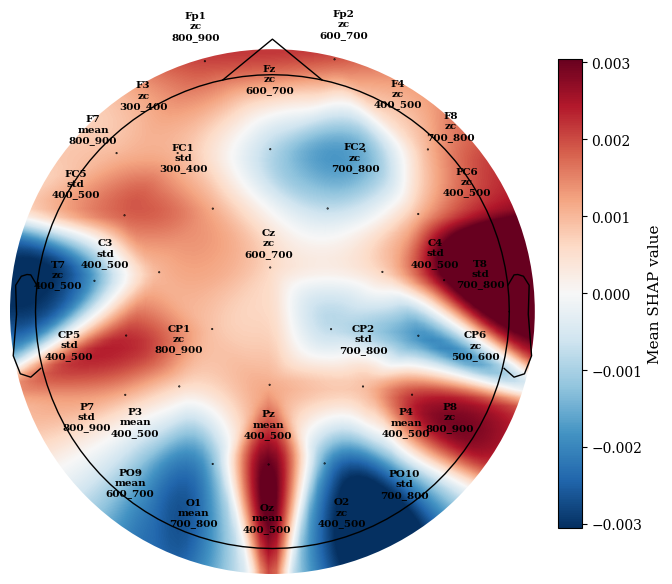

In [12]:
# Style for the thesis -> similar with Latex font
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",   # Latex-like math font
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# figure
fig, ax = plt.subplots(figsize=(7, 6))

values = best_features["importance"].values
vmax = np.max(np.abs(values)) # extract the highest absolute value for the ends of the colorbar

im, _ = mne.viz.plot_topomap(
    values,
    info_clean,
    axes=ax,
    cmap="RdBu_r",
    vlim=(-vmax, vmax),
    contours=0,
    show=False
)

# colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label("Mean SHAP value", fontsize=11)

# labels at each channel -> use the positions from the montage
for i, (x, y) in enumerate(pos):

    label = best_features["label"].iloc[i]

    ax.text(
        x, y, # at each channel
        label,
        ha="center",
        va="center",
        fontsize=7.5,         
        fontweight="bold", 
        color="black"
    )

plt.tight_layout()
plt.savefig("shap_topomap_overall.pdf", bbox_inches="tight")
plt.show()

### Topomap grid by feature type and ERP window

C:\Users\maria\AppData\Local\Temp\ipykernel_20772\3583288988.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])  # keep space for colorbar


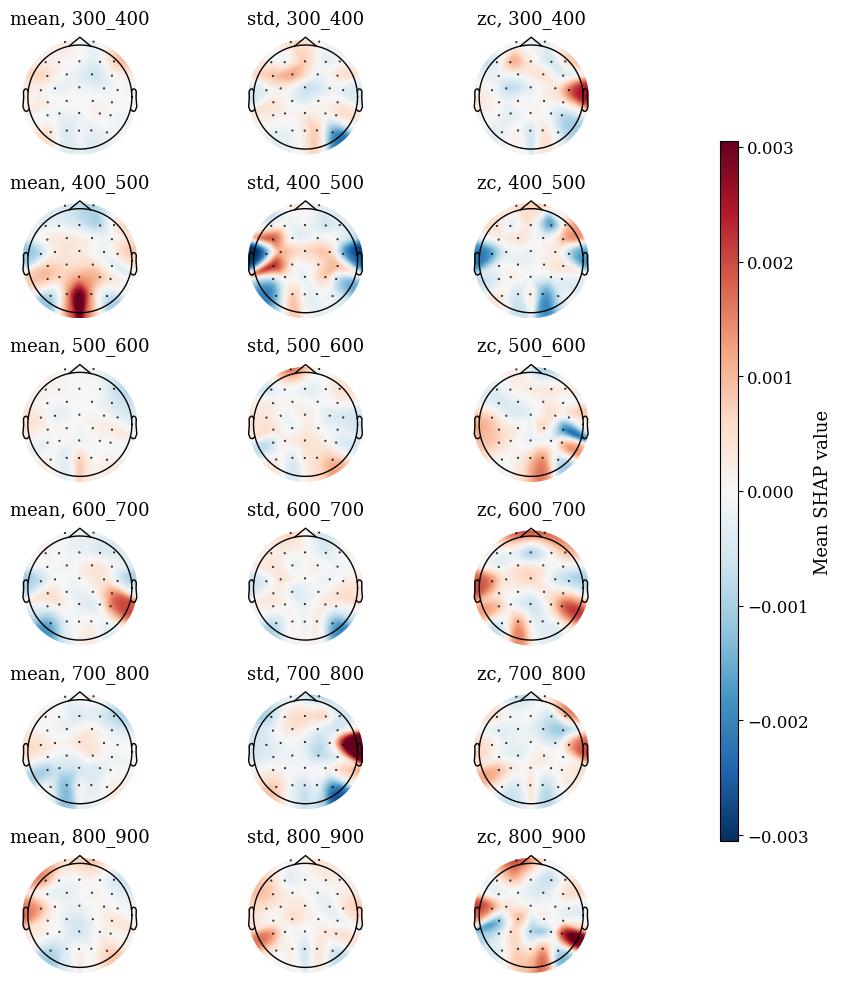

In [13]:
# Use same style
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

types = ["mean", "std", "zc"]
windows = ["300_400", "400_500", "500_600", "600_700", "700_800", "800_900"]

# Identify the highest absolute feature importance to use as a reference for all topomaps and for the colorbar
global_vmax = np.max(np.abs(feature_importance_df["importance"].values))

# figure
fig, axes = plt.subplots(len(windows), len(types), figsize=(9, 10))

# plot individual topomaps for each time window and feature types
for i, w in enumerate(windows):
    for j, t in enumerate(types):

        ax = axes[i, j] # position in the figure

        # extract details for each topomap
        subset = feature_importance_df[
            (feature_importance_df["window"] == w) &
            (feature_importance_df["type"] == t)
        ]

        # align the electrode column with the channel names used in mne.info
        subset = (subset.set_index("electrode").loc[ch_names].reset_index())
        values = subset["importance"].values # extract feature importance values

        im, _ = mne.viz.plot_topomap(
            values,
            info_clean,
            axes=ax,
            cmap="RdBu_r", 
            vlim=(-global_vmax, global_vmax), # same for each subtopomap
            contours=0,
            show=False
        )

        ax.set_title(f"{t}, {w}", fontsize=13)

# spacing the subplots
fig.subplots_adjust(right=0.88)

# colorbar, the same for every topomap for clear comparison
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Mean SHAP value", fontsize=13)

plt.tight_layout(rect=[0, 0, 0.88, 1])  # keep space for colorbar
plt.savefig("shap_grid.pdf", bbox_inches="tight")
plt.show()

In [14]:
# classic SHAP beeplot
shap.summary_plot(all_shap_values, all_X_test, max_display=20, show=False )

plt.savefig("bee.pdf", bbox_inches="tight")
plt.close()

### Importance by feature type -> mean, std, zc

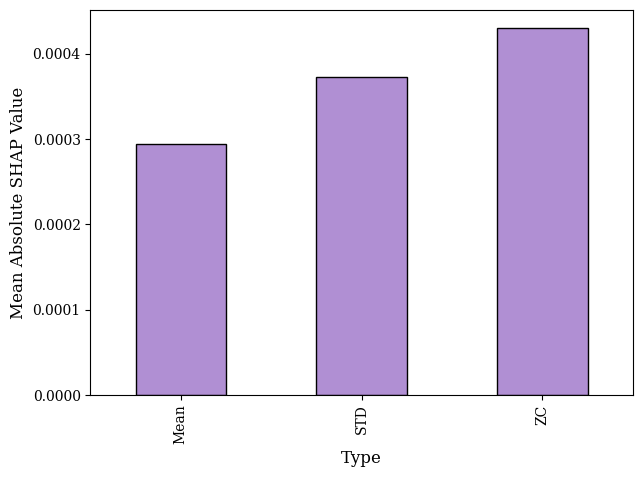

In [15]:
type_importance = (feature_importance_df.groupby("type")["abs_importance"].mean().reindex(["mean", "std", "zc"])) # calculate mean ABSOLUTE feature importance per feature type: mean, std, zc

# same plot style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

plt.figure(figsize=(7, 5))

type_importance.index = ["Mean", "STD", "ZC"]
type_importance.plot(kind="bar", color="#B08FD3", edgecolor="black")
plt.ylabel("Mean Absolute SHAP Value")
plt.xlabel("Type")
plt.savefig("per_metric.pdf", bbox_inches="tight")
plt.show()

### Importance by ERP window

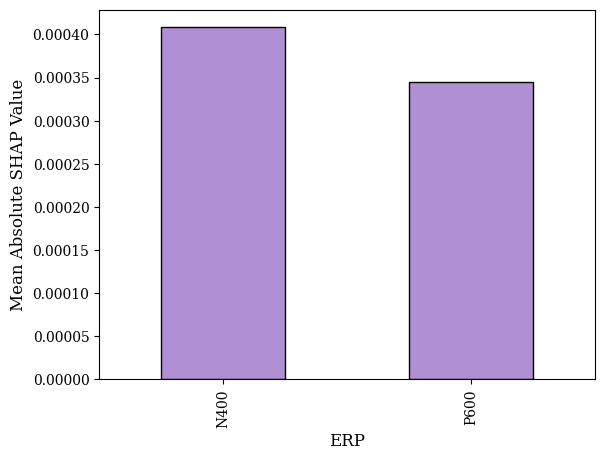

In [16]:
# To investigate whether features from the N400 window are more influential than those from the P600 window, label them based on the intervals in the feature names
def classify_erp(window):
    start = int(window.split("_")[0]) # extract the beginning of the interval
    if 300 <= start < 500: # if it starts with 300 or 400 -> N400 feature
        return "N400"
    elif 500 <= start < 900: # if it starts with 500, 600, 700 or 800 -> P600
        return "P600"
    else:
        return "Other" # safety net

feature_importance_df["ERP"] = feature_importance_df["window"].apply(classify_erp)

erp_importance = (feature_importance_df.groupby("ERP")["abs_importance"].mean().loc[["N400", "P600"]]) # mean ABSOLUTE feature importance by the corresponding ERP window

erp_importance.plot(kind="bar", color="#B08FD3", edgecolor="black")
plt.ylabel("Mean Absolute SHAP Value")
plt.savefig("per_erp.pdf", bbox_inches="tight")
plt.show()

### Group the 2 plots above for better thesis layout

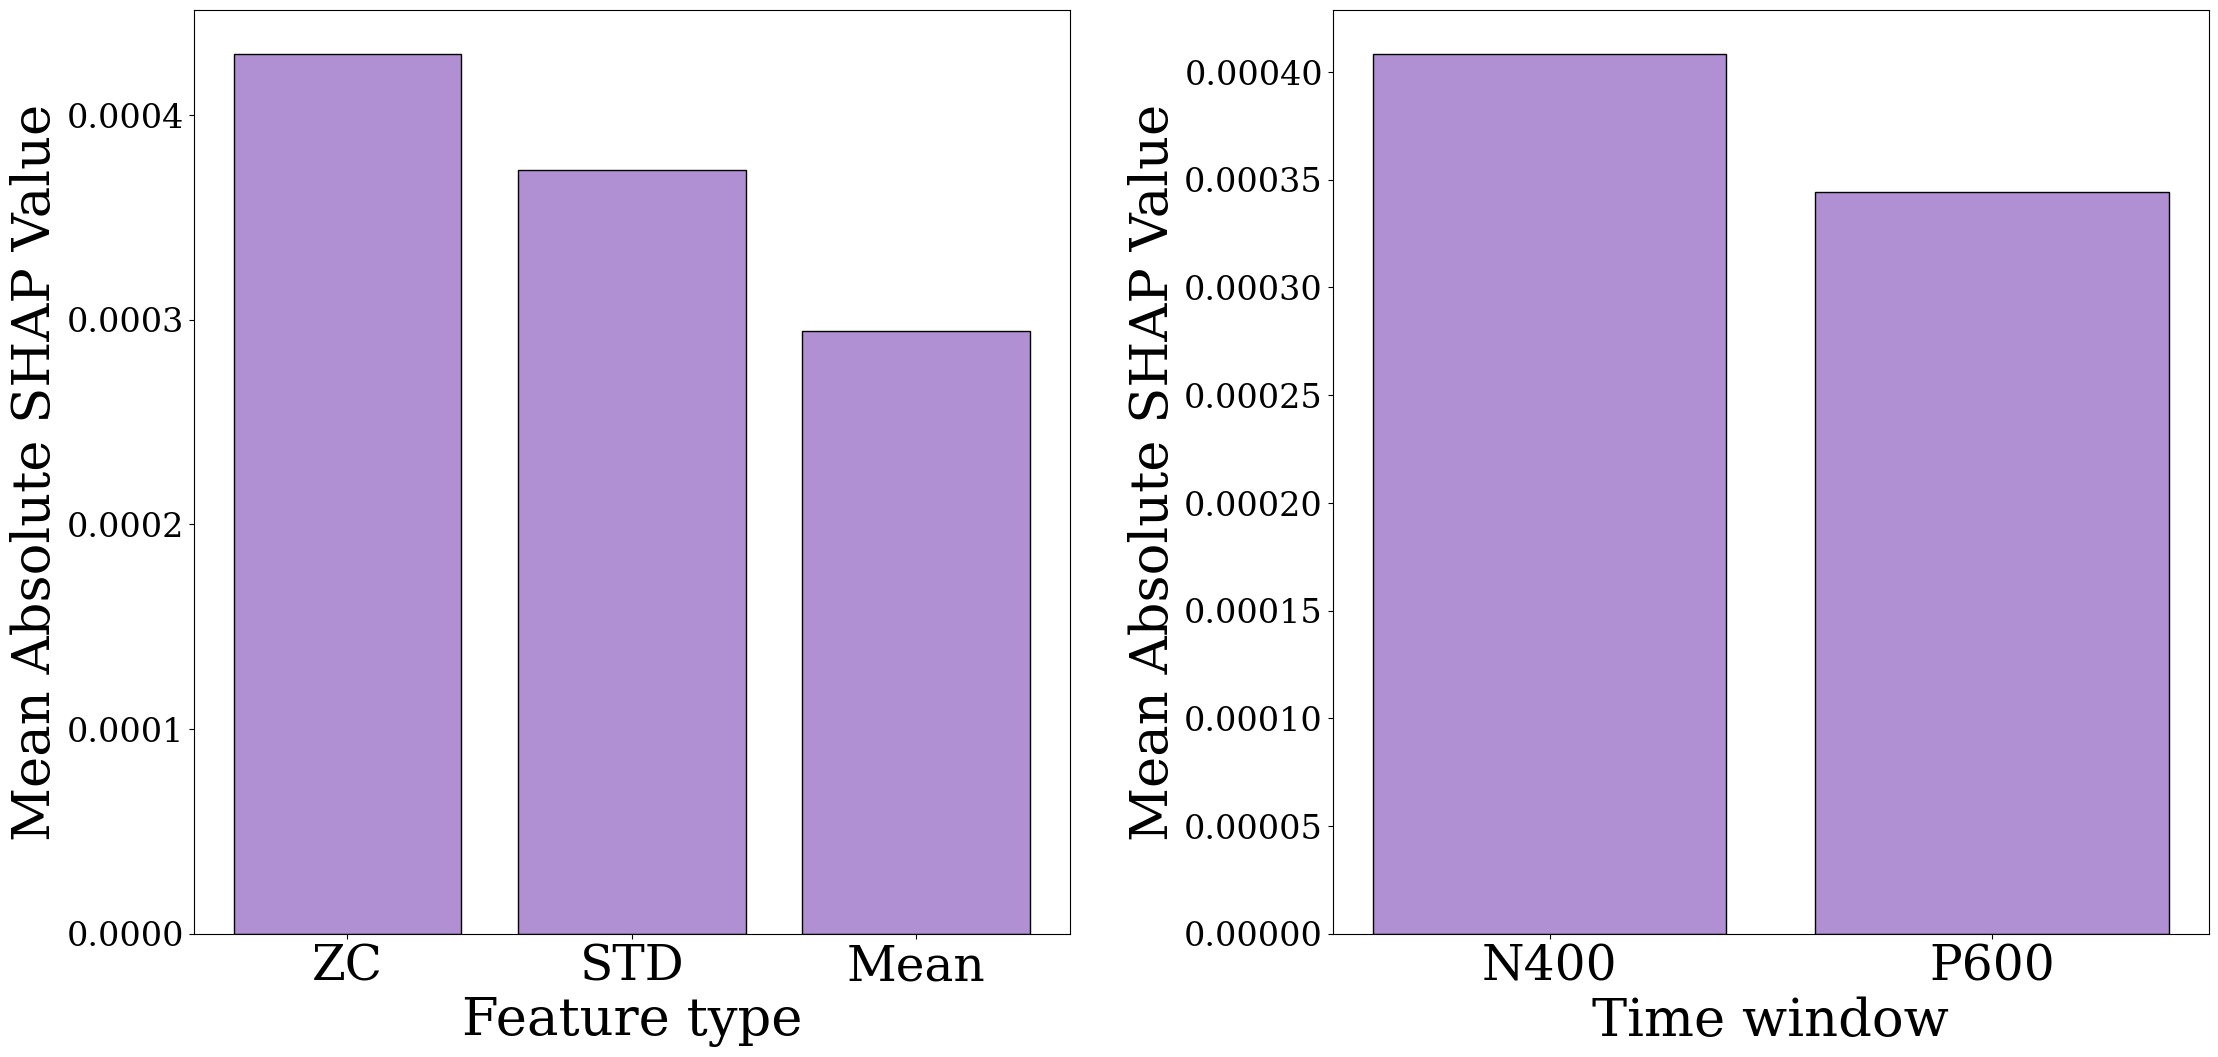

In [17]:
# calculate mean absolute feature importance per feature type: mean, std, zc
type_importance = (
    feature_importance_df
    .groupby("type")["abs_importance"]
    .mean()
    .reindex(["mean", "std", "zc"])
)
type_importance.index = ["Mean", "STD", "ZC"]
type_importance = type_importance.sort_values(ascending=False)

# to investigate whether features from the N400 window are more influential than those from the P600 window, label them based on the intervals in the feature names
def classify_erp(window):
    start = int(window.split("_")[0]) # extract the beginning of the interval
    if 300 <= start < 500: # if it starts with 300 or 400 -> N400 feature
        return "N400"
    elif 500 <= start < 900: # if it starts with 500, 600, 700 or 800 -> P600
        return "P600"
    else:
        return "Other" # outside N400/P600 range

feature_importance_df["ERP"] = feature_importance_df["window"].apply(classify_erp)

# mean absolute feature importance by the corresponding ERP window
erp_importance = (
    feature_importance_df
    .groupby("ERP")["abs_importance"]
    .mean()
    .loc[["N400", "P600"]]
    .sort_values(ascending=False)
)

# same style
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 34,
    "axes.titlesize": 38,
    "axes.labelsize": 38,
    "xtick.labelsize": 35,
    "ytick.labelsize": 24,
    "legend.fontsize": 34
})

# two panels side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(26, 12))
# space between them
plt.subplots_adjust(wspace=0.3)

# Left panel -> by feature type
ax1.bar(type_importance.index, type_importance.values,
        color="#B08FD3", edgecolor="black")
ax1.set_ylabel("Mean Absolute SHAP Value")
ax1.set_xlabel("Feature type")

# Right panel -> by ERP window
ax2.bar(erp_importance.index, erp_importance.values,
        color="#B08FD3", edgecolor="black")
ax2.set_ylabel("Mean Absolute SHAP Value")
ax2.set_xlabel("Time window")

plt.savefig("shap_importance_combined.pdf", bbox_inches="tight")
plt.show()

In [54]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn
import mne
import xgboost
import shap

print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"mne: {mne.__version__}")
print(f"xgboost: {xgboost.__version__}")
print(f"shap: {shap.__version__}")

pandas: 2.3.2
numpy: 2.2.6
matplotlib: 3.10.6
scikit-learn: 1.7.1
mne: 1.10.1
xgboost: 3.0.4
shap: 0.48.0
